# STalign parity: `merfish-xenium-alignment.ipynb`

Executed one-to-one replay of [the pinned upstream notebook](https://github.com/JEFworks-Lab/STalign/blob/b2068edc98974efa54537eca194736e177bbe11d/docs/notebooks/merfish-xenium-alignment.ipynb).

Status: `compared`. 


In [1]:
# per-variable relative L2: upstream STalign vs the squidpy JAX port


{
  "A relative L2": 2.4082929798561408e-05,
  "df1[Unnamed: 0] label disagreement": 0.0,
  "df1[Unnamed: 0] label set jaccard": 1.0,
  "df1[Unnamed: 0] labels only squidpy": 0.0,
  "df1[Unnamed: 0] labels only upstream": 0.0,
  "df1[center_x] median abs delta": 0.0,
  "df1[center_y] median abs delta": 0.0,
  "df1[max_x] median abs delta": 0.0,
  "df1[max_y] median abs delta": 0.0,
  "df1[min_x] median abs delta": 0.0,
  "df1[min_y] median abs delta": 0.0,
  "df1[volume] median abs delta": 0.0,
  "df2 relative L2": 0.0,
  "df2[cell_area] median abs delta": 0.0,
  "df2[nucleus_area] median abs delta": 0.0,
  "df2[x_centroid] median abs delta": 0.0,
  "df2[y_centroid] median abs delta": 0.0,
  "extentI relative L2": 0.0,
  "extentJ relative L2": 0.0,
  "levels relative L2": 0.0,
  "phi relative L2": 5.30888443652852e-07,
  "phiI relative L2": 9.34653610621217e-06,
  "phii relative L2": 5.221093224328937e-07,
  "phiiJ relative L2": 9.624528552330233e-06,
  "tpointsI relative L2": 0.0,
  "

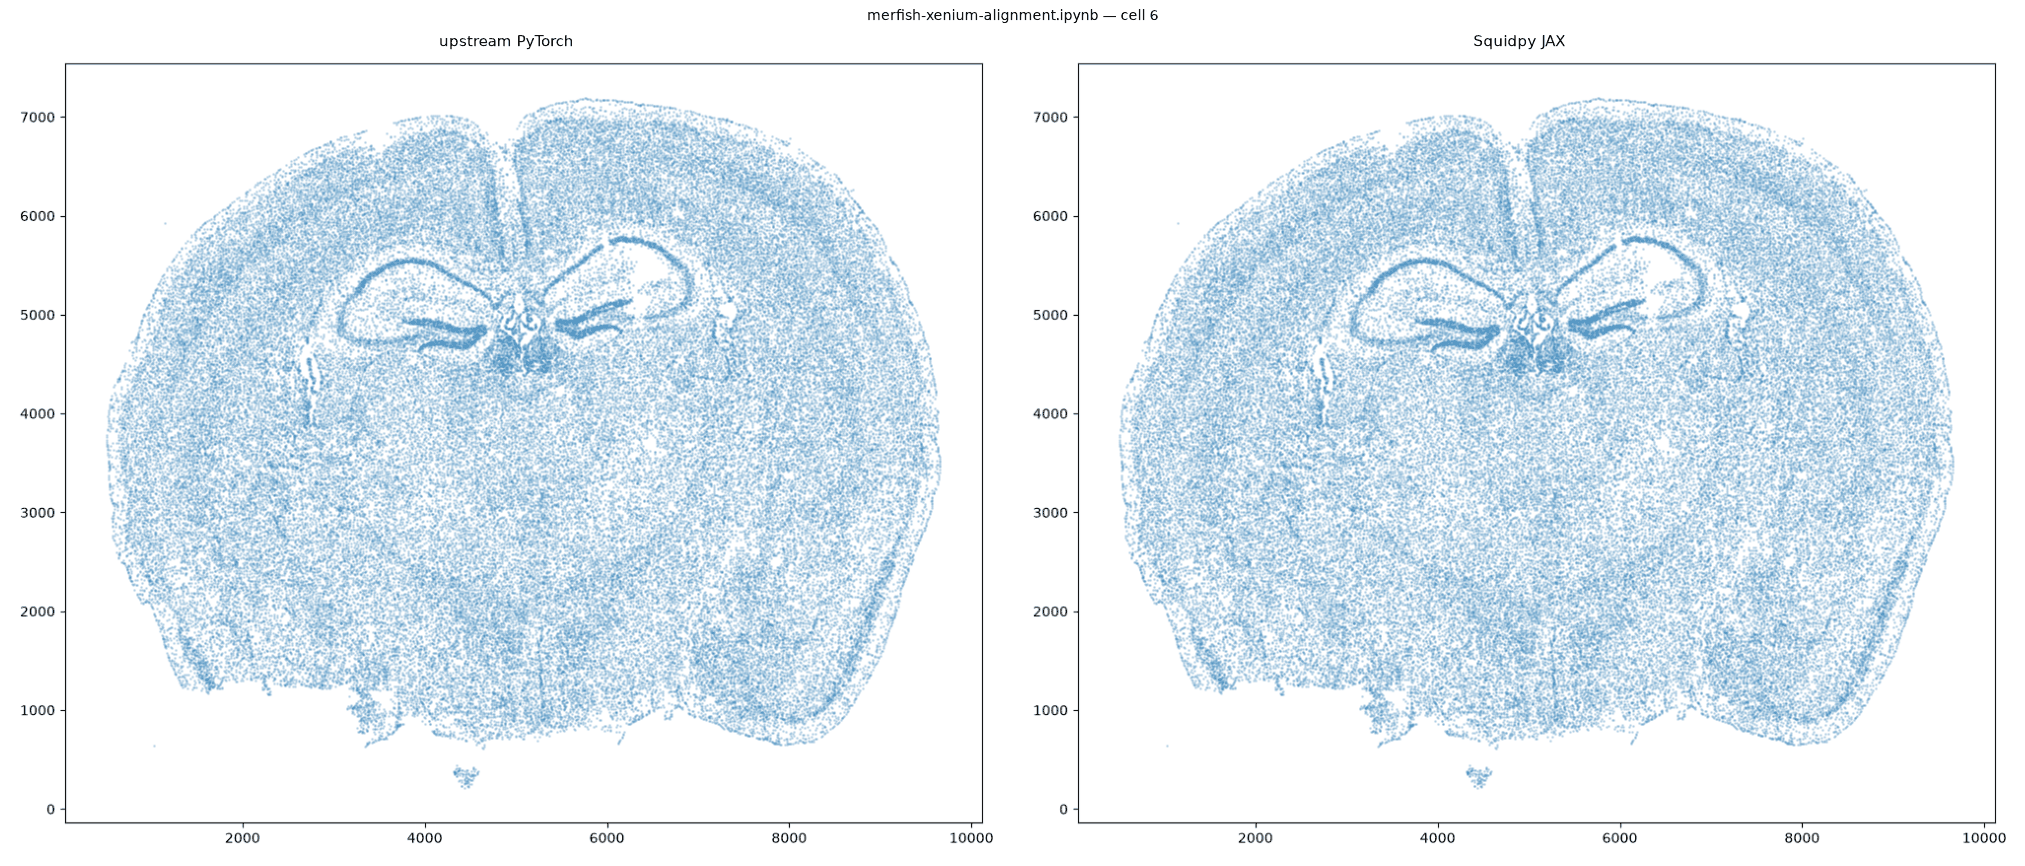

In [2]:
# get cell centroid coordinates
xI = np.array(df1['center_x'])
yI = np.array(df1['center_y'])

# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2)

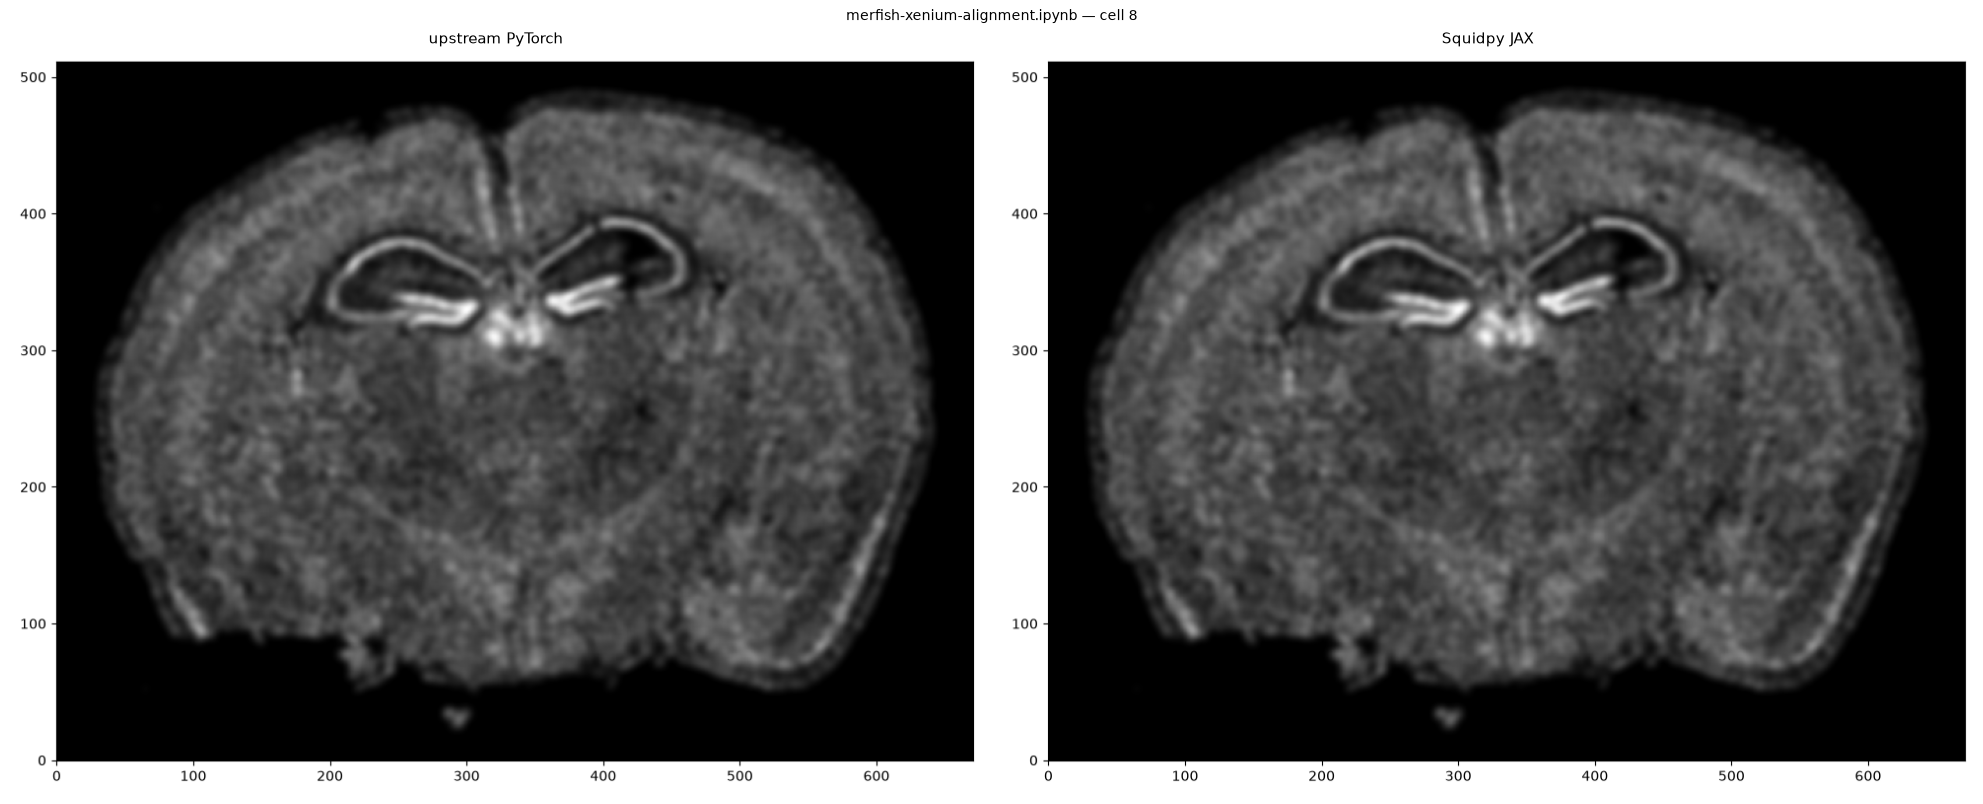

In [3]:
# rasterize at 30um resolution (assuming positions are in um units) and plot
XI,YI,I,fig = STalign.rasterize(xI,yI,dx=15,blur=1.5)

# plot
ax = fig.axes[0]
ax.invert_yaxis()

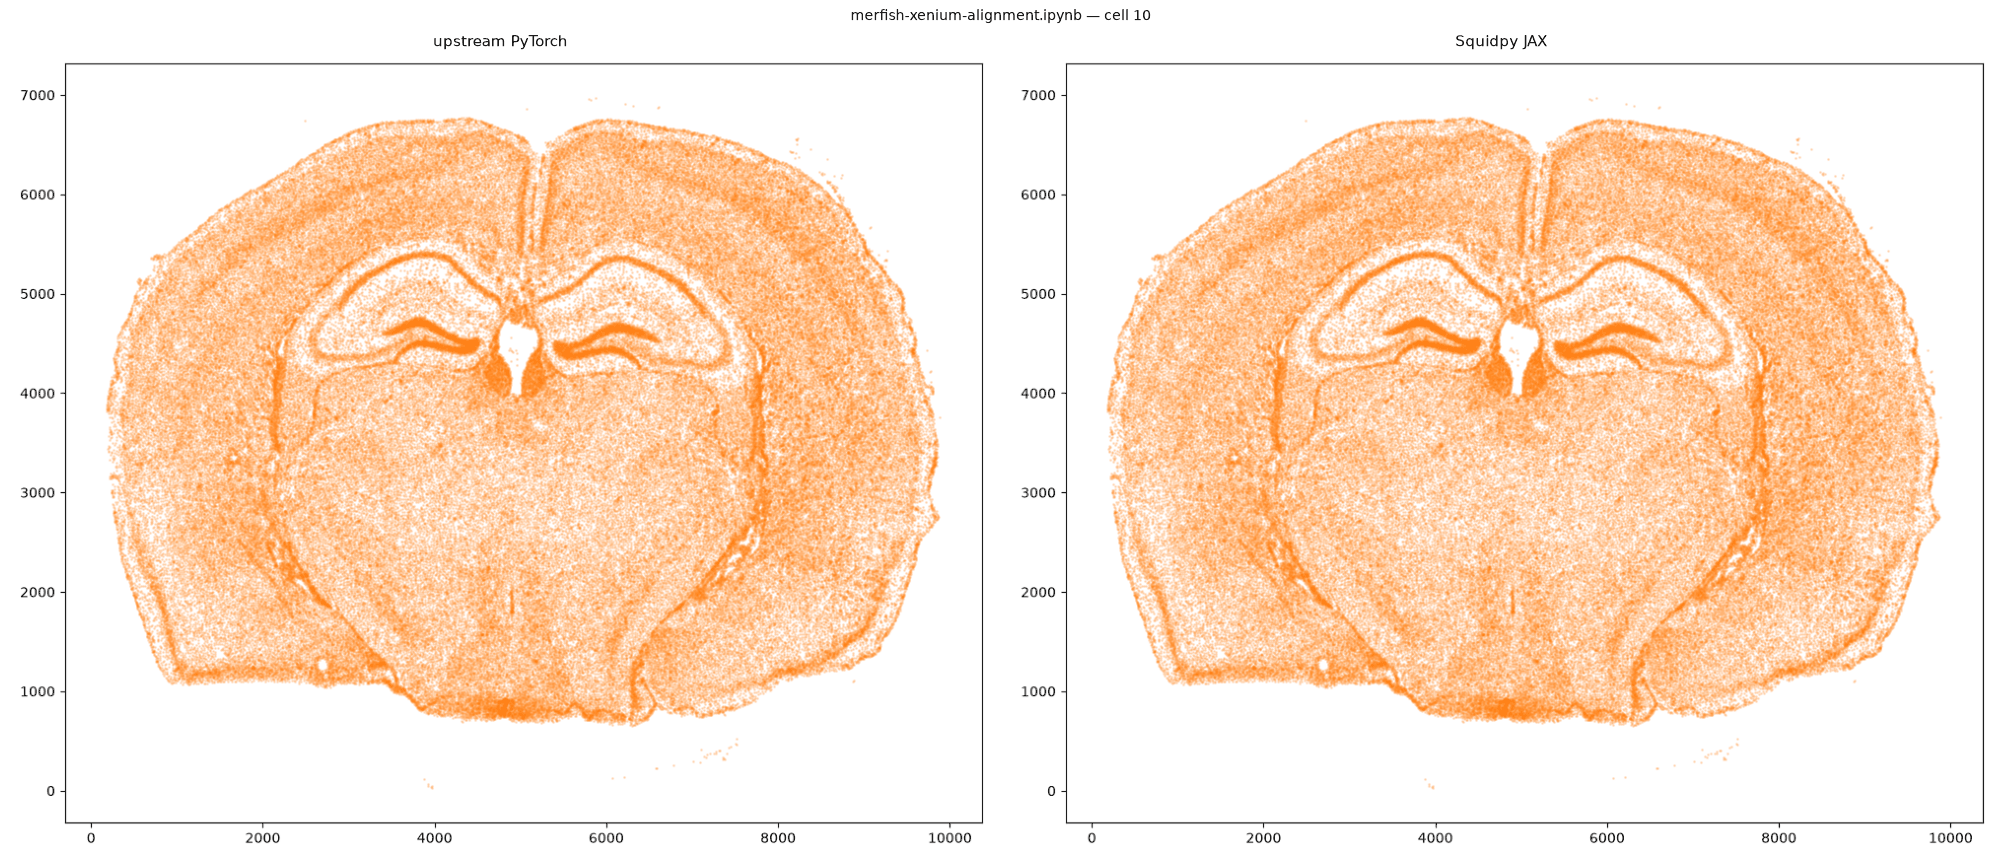

In [4]:
# Single cell data 2
# read in data
fname = '../../xenium_data/Xenium_V1_FF_Mouse_Brain_MultiSection_1_cells.csv.gz'
df2 = pd.read_csv(fname)

# get cell centroids
xJ = np.array(df2['x_centroid'])
yJ = np.array(df2['y_centroid'])

# plot
fig,ax = plt.subplots()
ax.scatter(xJ,yJ,s=1,alpha=0.2,c='#ff7f0e')

# rasterize and plot
XJ,YJ,J,fig = STalign.rasterize(xJ,yJ,dx=15, blur=1.5)
ax = fig.axes[0]
ax.invert_yaxis()

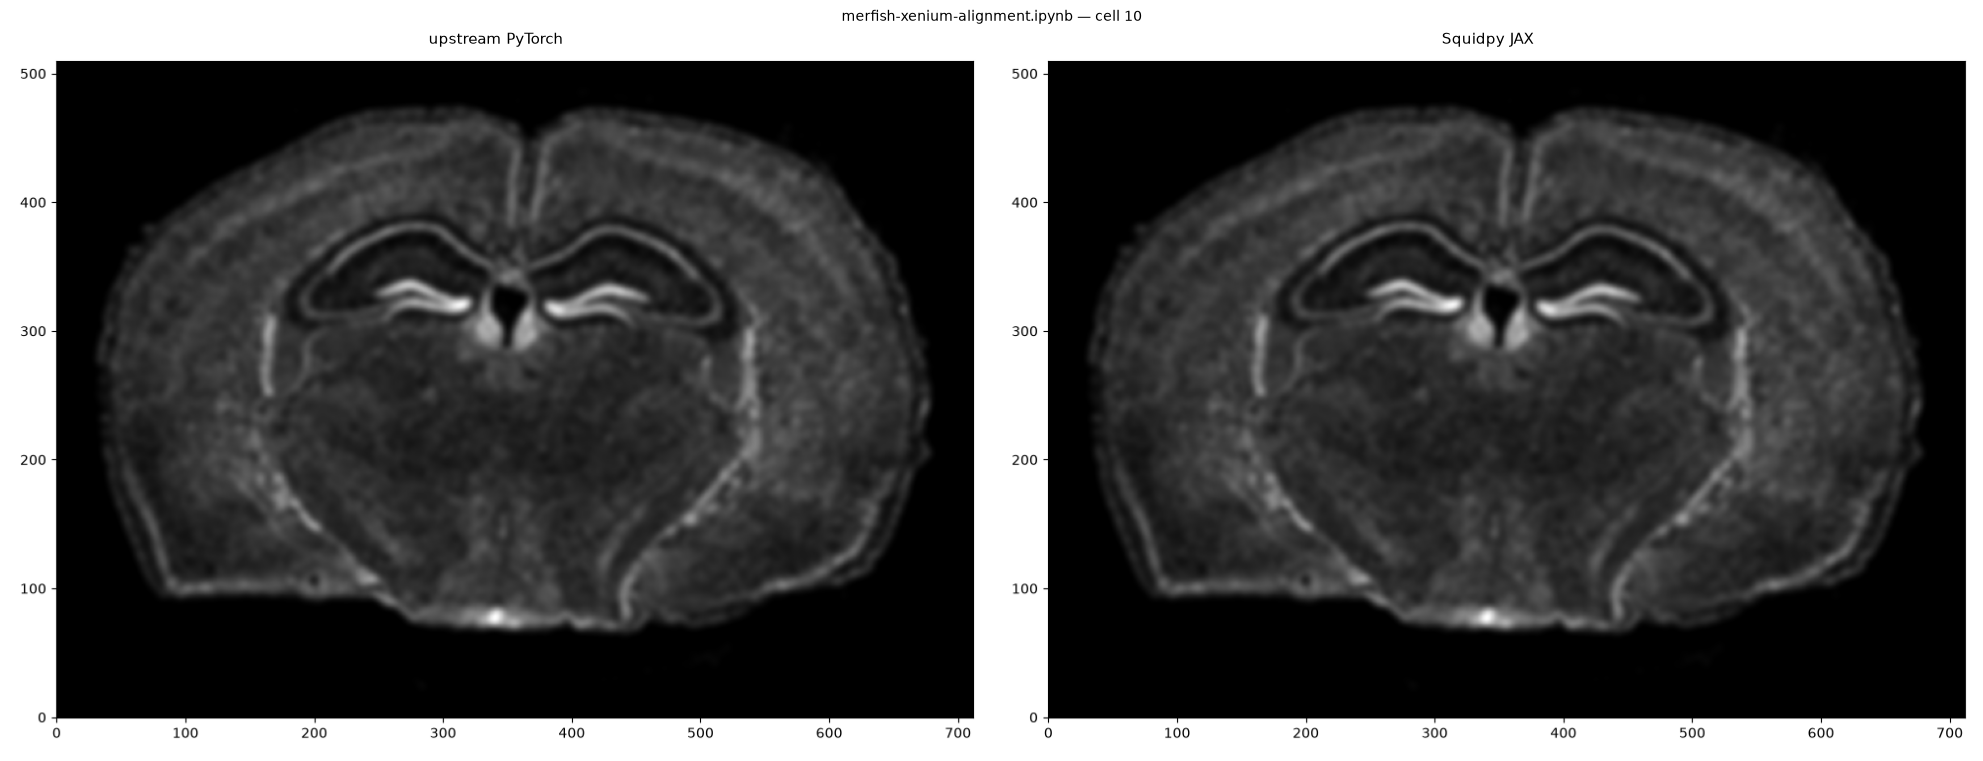

In [5]:
# Single cell data 2
# read in data
fname = '../../xenium_data/Xenium_V1_FF_Mouse_Brain_MultiSection_1_cells.csv.gz'
df2 = pd.read_csv(fname)

# get cell centroids
xJ = np.array(df2['x_centroid'])
yJ = np.array(df2['y_centroid'])

# plot
fig,ax = plt.subplots()
ax.scatter(xJ,yJ,s=1,alpha=0.2,c='#ff7f0e')

# rasterize and plot
XJ,YJ,J,fig = STalign.rasterize(xJ,yJ,dx=15, blur=1.5)
ax = fig.axes[0]
ax.invert_yaxis()

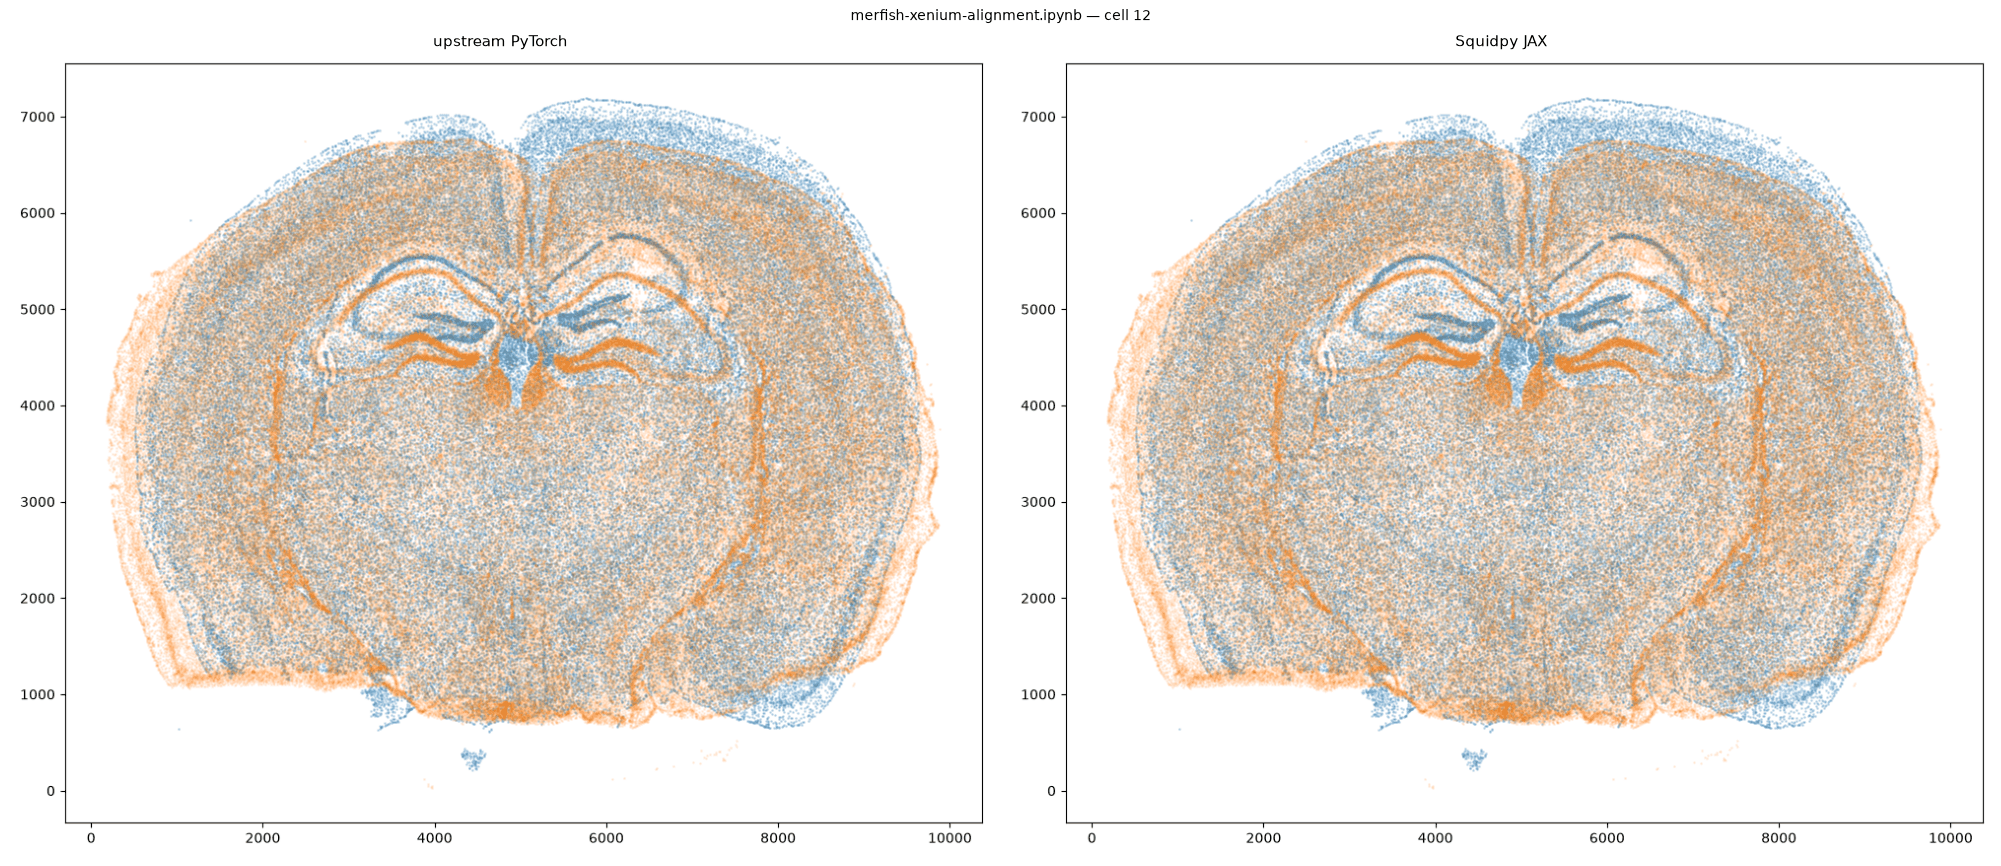

In [6]:
# plot
fig,ax = plt.subplots()
ax.scatter(xI,yI,s=1,alpha=0.2)
ax.scatter(xJ,yJ,s=1,alpha=0.1)

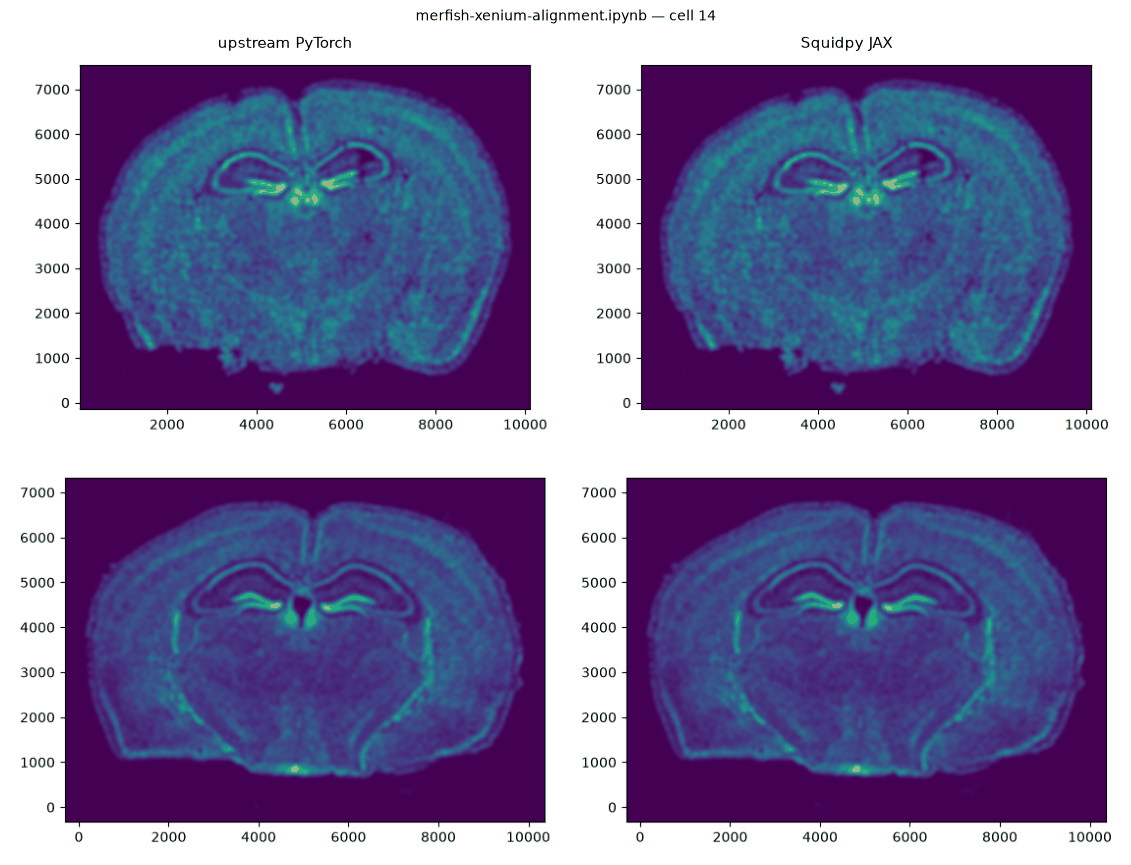

In [7]:
# get extent of images
extentI = STalign.extent_from_x((YI,XI))
extentJ = STalign.extent_from_x((YJ,XJ))

# plot rasterized images
fig,ax = plt.subplots(2,1)
ax[0].imshow((I.transpose(1,2,0).squeeze()), extent=extentI) # just want 201x276 matrix
ax[1].imshow((J.transpose(1,2,0).squeeze()), extent=extentJ) # just want 201x276 matrix
ax[0].invert_yaxis()
ax[1].invert_yaxis()

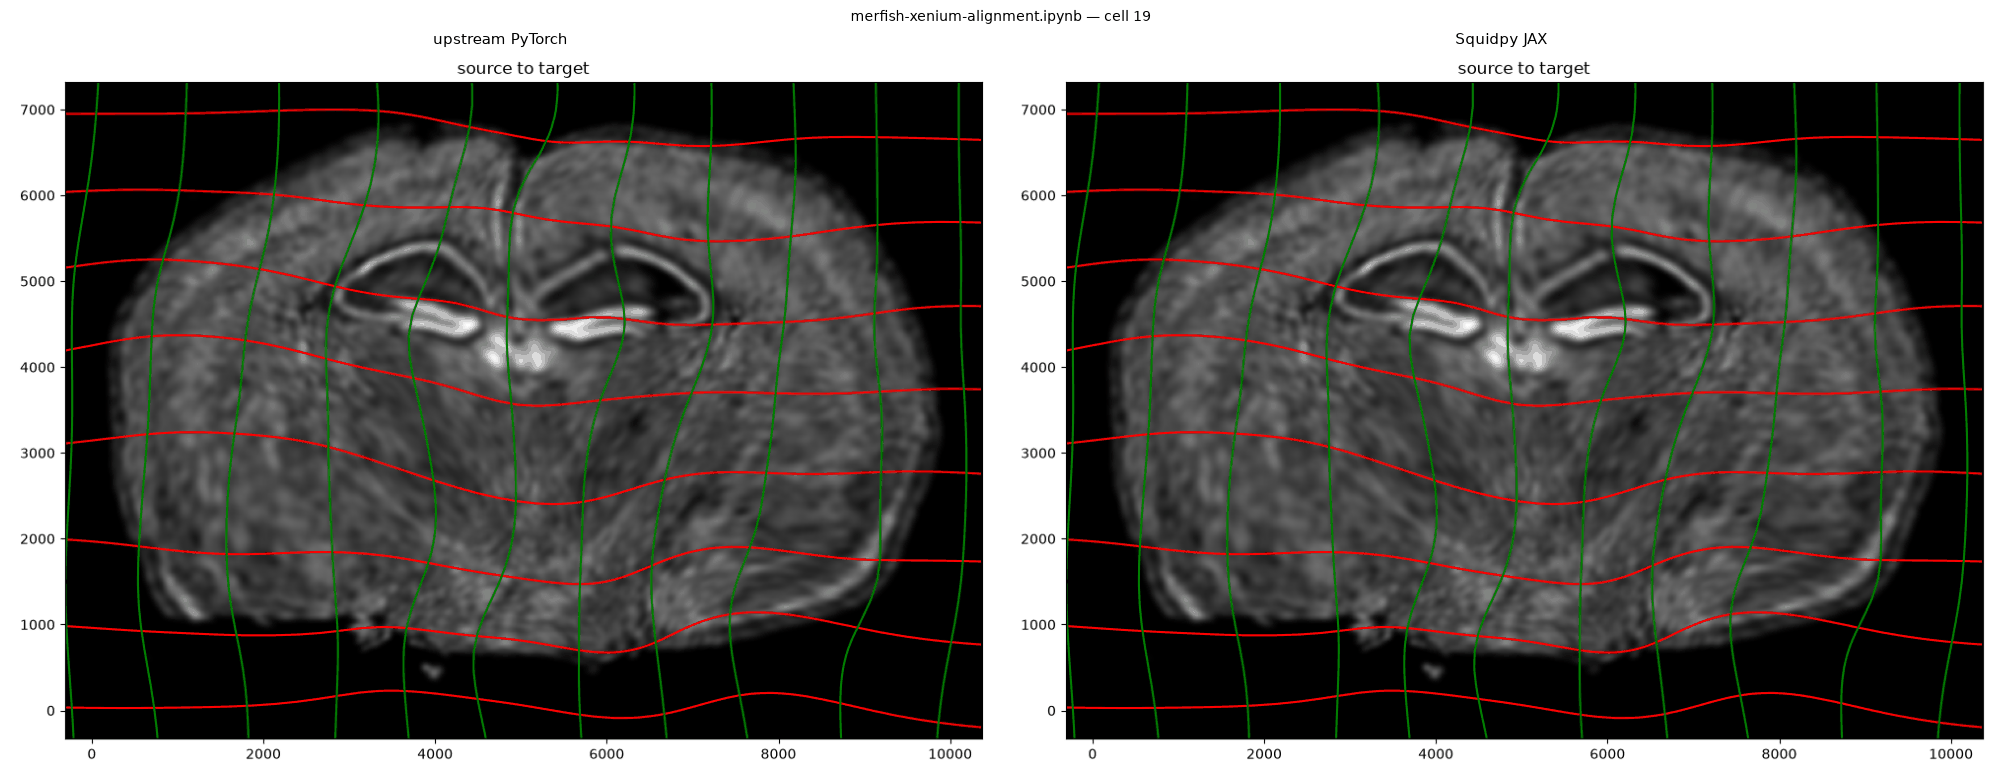

In [8]:
# apply transform
phii = STalign.build_transform(xv,v,A,XJ=[YJ,XJ],direction='b')
phiI = STalign.transform_image_source_to_target(xv,v,A,[YI,XI],Ifoo,[YJ,XJ])

# plot with grids
fig,ax = plt.subplots()
levels = np.arange(-100000,100000,1000)
ax.contour(XJ,YJ,phii[...,0],colors='r',linestyles='-',levels=levels)
ax.contour(XJ,YJ,phii[...,1],colors='g',linestyles='-',levels=levels)
ax.set_aspect('equal')
ax.set_title('source to target')
ax.imshow(phiI.permute(1,2,0)/torch.max(phiI),extent=extentJ)
ax.invert_yaxis()

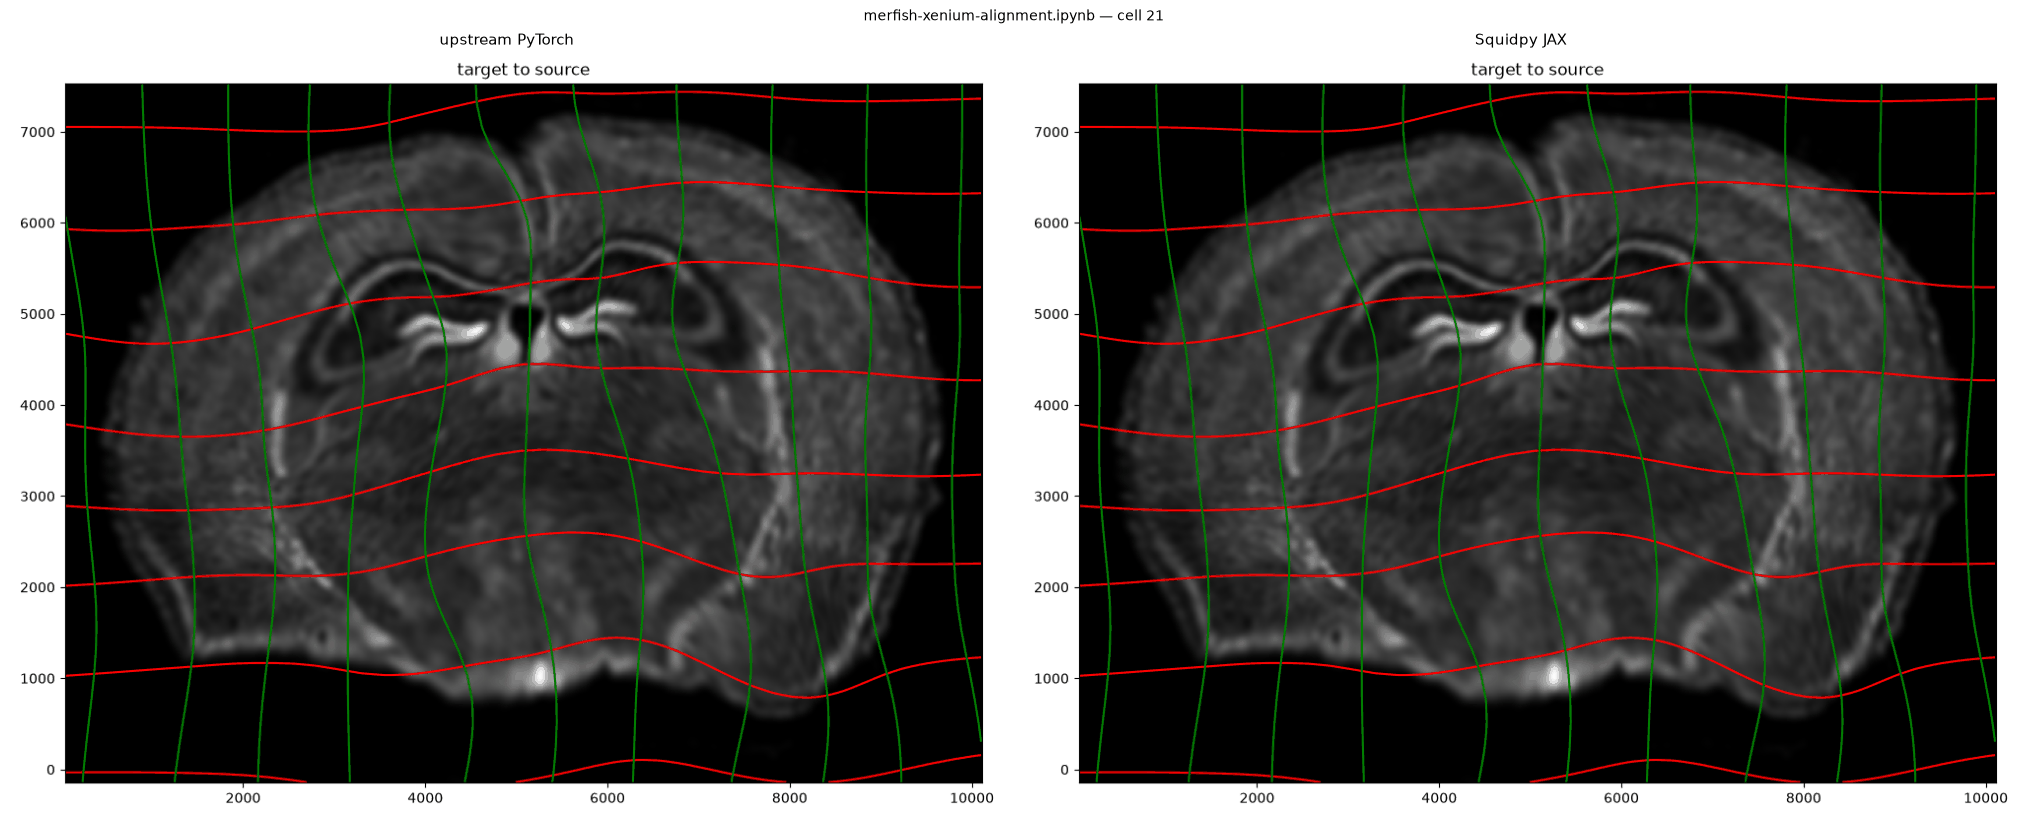

In [9]:
# transform is invertible
phi = STalign.build_transform(xv,v,A,XJ=[YI,XI],direction='f')
phiiJ = STalign.transform_image_target_to_source(xv,v,A,[YJ,XJ],Jfoo,[YI,XI])

# plot with grids
fig,ax = plt.subplots()
levels = np.arange(-100000,100000,1000)
ax.contour(XI,YI,phi[...,0],colors='r',linestyles='-',levels=levels)
ax.contour(XI,YI,phi[...,1],colors='g',linestyles='-',levels=levels)
ax.set_aspect('equal')
ax.set_title('target to source')
ax.imshow(phiiJ.permute(1,2,0)/torch.max(phiiJ),extent=extentI)
ax.invert_yaxis()

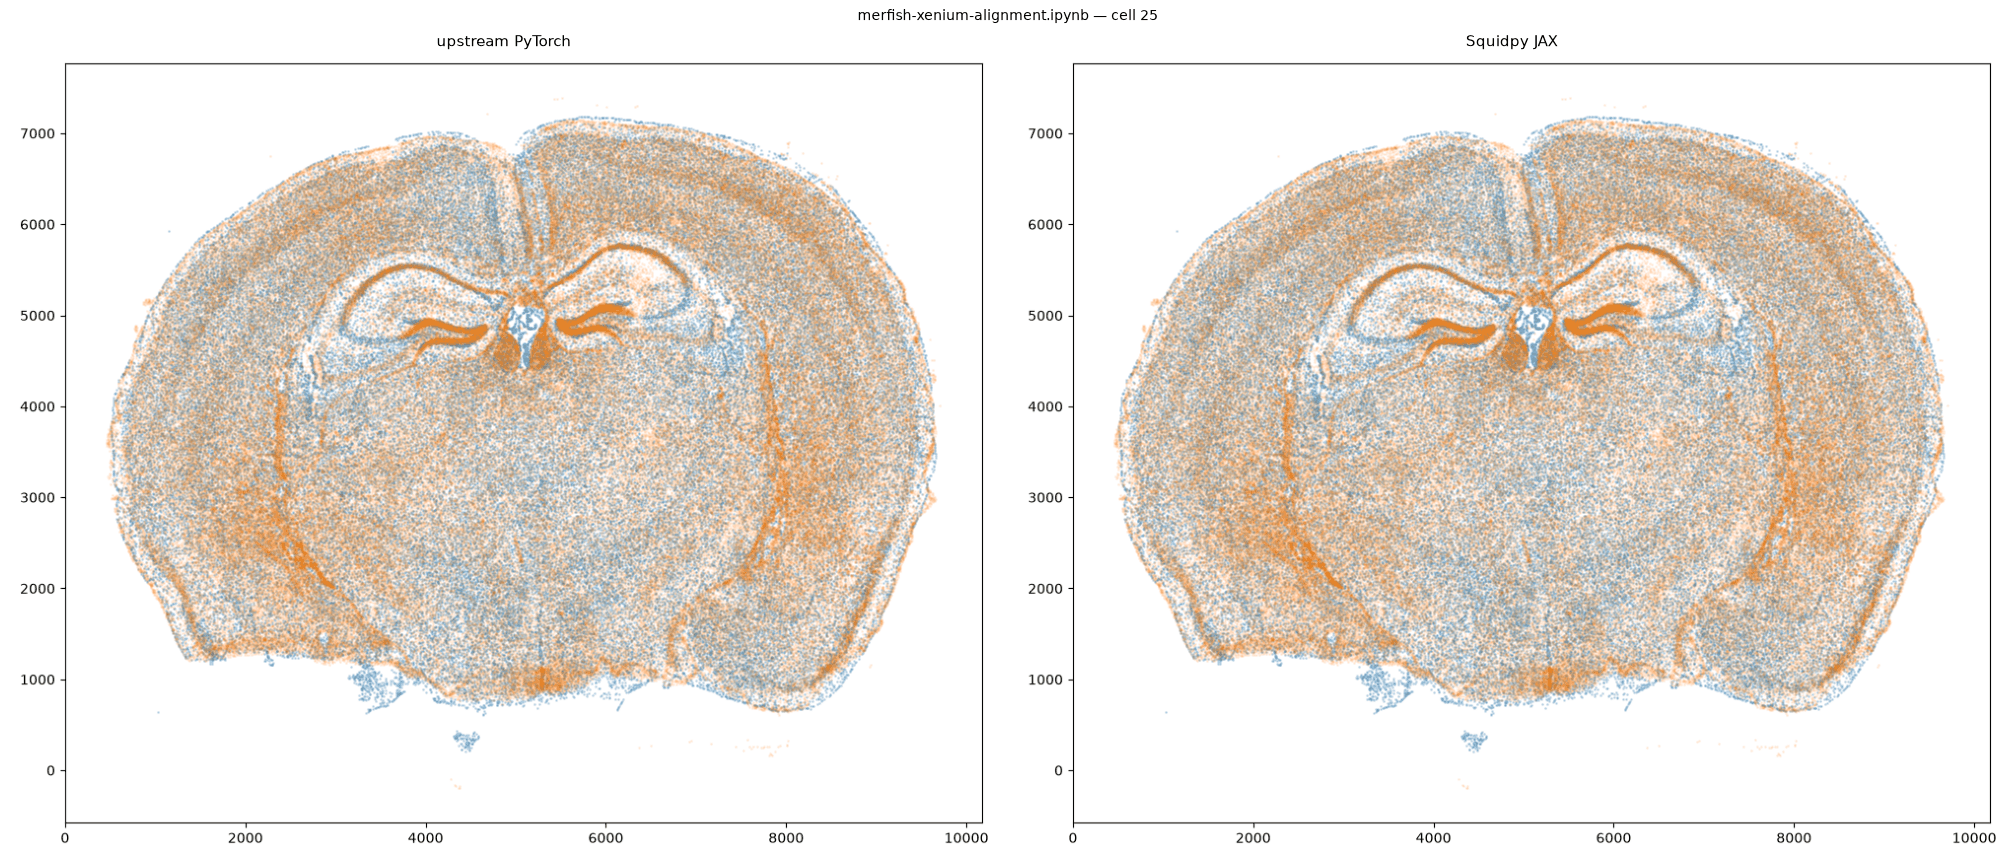

In [10]:
# plot results
fig,ax = plt.subplots()
ax.scatter(tpointsI[0,:],tpointsI[1,:],s=1,alpha=0.2) 
ax.scatter(tpointsJ[:,1],tpointsJ[:,0],s=1,alpha=0.1) # also needs to plot as y,x not x,y

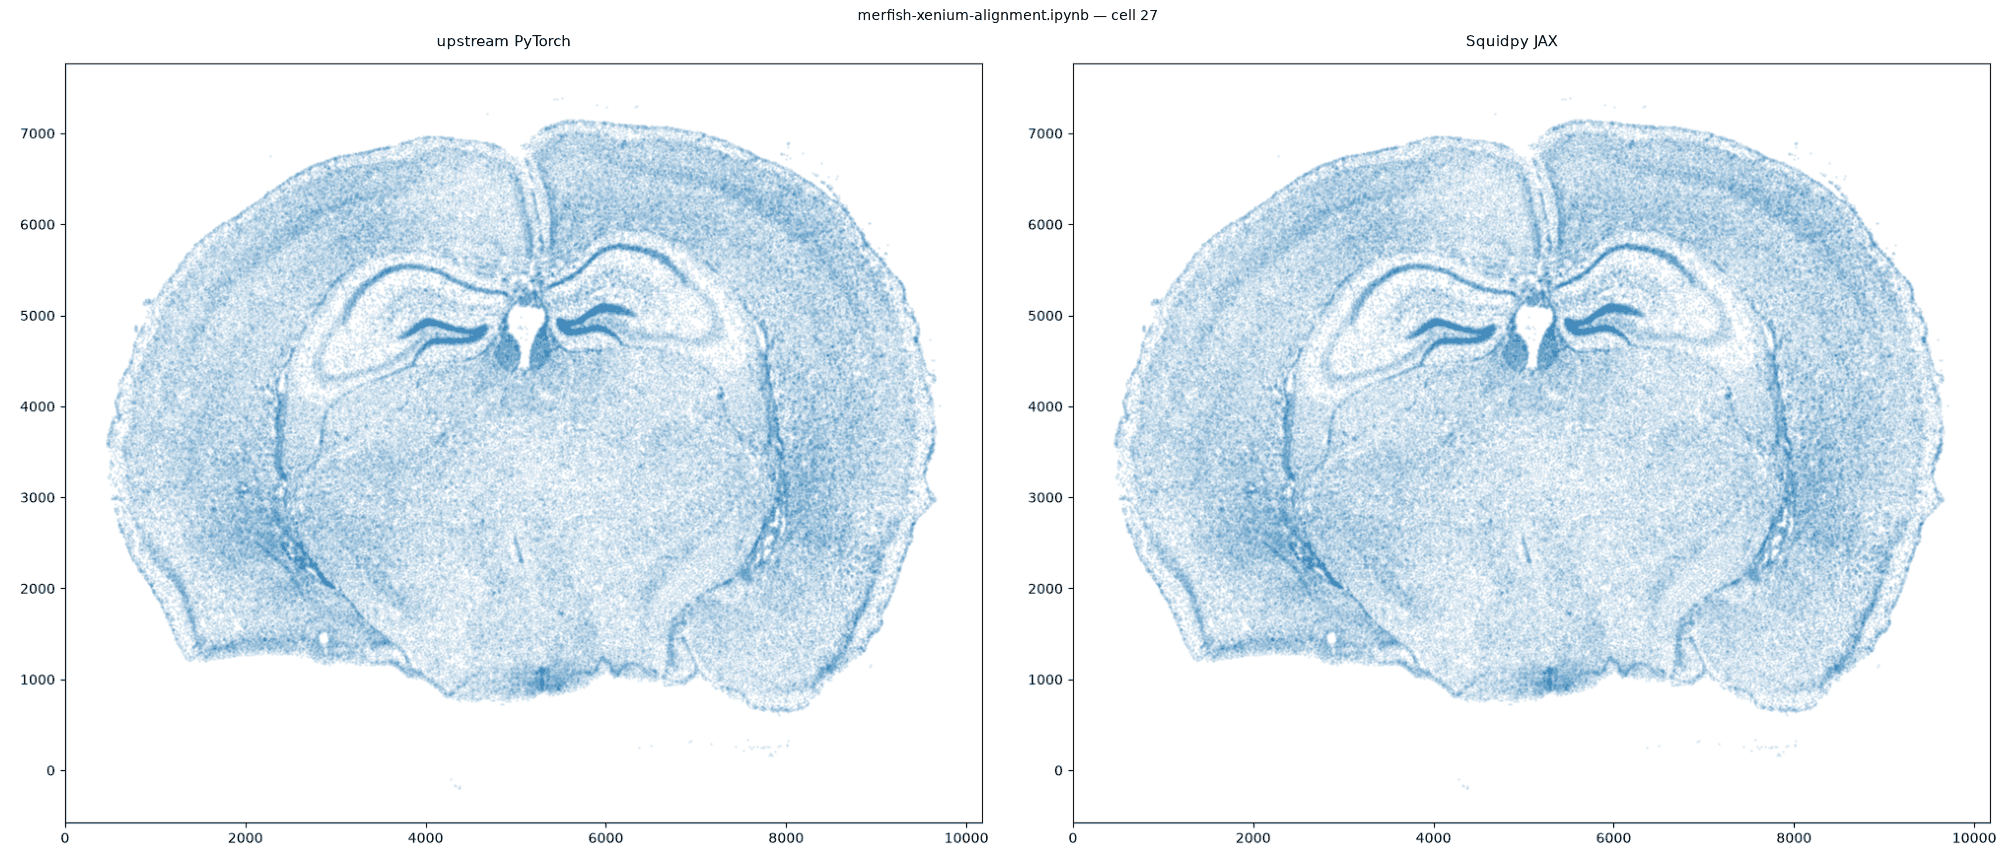

In [11]:
fig,ax = plt.subplots()
ax.scatter(tpointsJ[:,1],tpointsJ[:,0],s=1,alpha=0.1) # also needs to plot as y,x not x,y